In [2]:
import pandas as pd
import numpy as np
import optuna
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTENC
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# ---------------------------------------------------------
# 1. Load the Datasets & Transform to Binary
# ---------------------------------------------------------
print("Loading datasets...")

DATA_PATH = '../tp/processed_datasets/'
X_TRAIN_PATH = DATA_PATH + 'X_train_catboost.parquet'
X_VAL_PATH = DATA_PATH + 'X_val_catboost.parquet'
X_TEST_PATH = DATA_PATH + 'X_test_catboost.parquet'

Y_TRAIN_PATH = DATA_PATH + 'y_train.csv'
Y_VAL_PATH = DATA_PATH + 'y_val.csv'
Y_TEST_PATH = DATA_PATH + 'y_test.csv'

X_train = pd.read_parquet(X_TRAIN_PATH, engine="fastparquet")
X_val = pd.read_parquet(X_VAL_PATH, engine="fastparquet")
X_test = pd.read_parquet(X_TEST_PATH, engine="fastparquet")

y_train_raw = pd.read_csv(Y_TRAIN_PATH).squeeze()
y_val_raw = pd.read_csv(Y_VAL_PATH).squeeze()
y_test_raw = pd.read_csv(Y_TEST_PATH).squeeze()

# Transfrom (0,1,2,3,4) to (0,1,2)

y_train = np.clip(y_train_raw, 0, 2)
y_val   = np.clip(y_val_raw, 0, 2)
y_test  = np.clip(y_test_raw, 0, 2)

print(f"Target distribution (Train):\n{y_train.value_counts(normalize=True)}")
print(f"Train shapes: X={X_train.shape}, y={y_train.shape}")

categorical_features = X_train.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
categorical_features.extend(['DAY_OF_WEEK'])
print(f"Detected {len(categorical_features)} categorical features.")

Loading datasets...
Target distribution (Train):
DAMAGE_CLASS
0    0.615161
2    0.215717
1    0.169122
Name: proportion, dtype: float64
Train shapes: X=(876565, 32), y=(876565,)
Detected 11 categorical features.


In [4]:
# ---------------------------------------------------------
# 1.5. Apply SMOTENC to Balance Classes
# ---------------------------------------------------------
print("Applying SMOTENC...")
# Get indices of categorical features for SMOTENC
cat_indices = [X_train.columns.get_loc(col) for col in categorical_features]

smote = SMOTENC(categorical_features=cat_indices, random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"Resampled Target distribution (Train):\n{y_train_res.value_counts(normalize=True)}")
print(f"Resampled Train shapes: X={X_train_res.shape}, y={y_train_res.shape}")

Applying SMOTENC...
Resampled Target distribution (Train):
DAMAGE_CLASS
2    0.333333
0    0.333333
1    0.333333
Name: proportion, dtype: float64
Resampled Train shapes: X=(1617687, 32), y=(1617687,)


In [5]:
# ---------------------------------------------------------
# 2. Define the Optuna Objective Function
# ---------------------------------------------------------
def objective(trial):
    params = {
        "iterations": 2000,
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "random_strength": trial.suggest_float("random_strength", 1, 10),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 1),
        "grow_policy": trial.suggest_categorical("grow_policy", ["SymmetricTree", "Depthwise", "Lossguide"]),
        "random_seed": 42,
        "verbose": False,
        "task_type": "GPU",
        "eval_metric": "TotalF1:average=Weighted"
    }
    
    model = CatBoostClassifier(**params)

    model.fit(
        X_train_res, 
        y_train_res,
        cat_features=categorical_features,
        eval_set=[(X_val, y_val)],
        early_stopping_rounds=100, 
        use_best_model=True
    )

    preds_class = np.squeeze(model.predict(X_val))
    # Optimizamos weighted f1 por el desbalance de clases
    score = f1_score(y_val, preds_class, average='weighted')
    
    return score

In [6]:
# ---------------------------------------------------------
# 3. Run the Optuna Study
# ---------------------------------------------------------
print("Starting Optuna hyperparameter...")

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print("\n--- Optimization Finished ---")
print(f"Best Weighted F1: {study.best_value:.4f}")
print("Best Parameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2026-06-16 22:31:35,583] A new study created in memory with name: no-name-1677072f-9c86-4875-965f-2223c7ab977d


Starting Optuna hyperparameter...


[I 2026-06-16 22:34:35,766] Trial 0 finished with value: 0.8513328286029551 and parameters: {'learning_rate': 0.0026394033567382555, 'depth': 8, 'l2_leaf_reg': 9.286760111516456, 'random_strength': 9.845109603837528, 'bagging_temperature': 0.6795117758440735, 'grow_policy': 'Depthwise'}. Best is trial 0 with value: 0.8513328286029551.
[I 2026-06-16 22:34:54,390] Trial 1 finished with value: 0.7954681759472196 and parameters: {'learning_rate': 0.0010434676290265452, 'depth': 6, 'l2_leaf_reg': 6.695778476919744, 'random_strength': 4.687573651487872, 'bagging_temperature': 0.8097135448082317, 'grow_policy': 'Lossguide'}. Best is trial 0 with value: 0.8513328286029551.
[I 2026-06-16 22:35:10,594] Trial 2 finished with value: 0.797560188768473 and parameters: {'learning_rate': 0.00544195765368802, 'depth': 9, 'l2_leaf_reg': 6.2755094794736035, 'random_strength': 3.2849810186354644, 'bagging_temperature': 0.9895162199108742, 'grow_policy': 'Lossguide'}. Best is trial 0 with value: 0.85133282


--- Optimization Finished ---
Best Weighted F1: 0.8632
Best Parameters:
  learning_rate: 0.02596097849559803
  depth: 9
  l2_leaf_reg: 5.557588255735388
  random_strength: 5.428310090075387
  bagging_temperature: 0.5787584298688968
  grow_policy: Depthwise


In [7]:
# ---------------------------------------------------------
# 4. Train Final Model & Evaluate on Test Set
# ---------------------------------------------------------
print("\nTraining final binary model...")

final_params = study.best_params.copy()
final_params.update({
    "iterations": 2000,
    "random_seed": 42,
    "verbose": False,
    "task_type": "GPU"
})

final_model = CatBoostClassifier(**final_params)

final_model.fit(
    X_train_res, 
    y_train_res,
    cat_features=categorical_features,
    eval_set=[(X_val, y_val)],
    early_stopping_rounds=100,
    use_best_model=True
)

y_pred = final_model.predict(X_test)
print(f"Final Test Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Training final binary model...
Final Test Accuracy: 0.8445

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.93      0.92     86950
           1       0.69      0.67      0.68     17859
           2       0.50      0.44      0.47     11189

    accuracy                           0.84    115998
   macro avg       0.70      0.68      0.69    115998
weighted avg       0.84      0.84      0.84    115998

Confusion Matrix:
[[81082  2982  2886]
 [ 3889 11963  2007]
 [ 3779  2500  4910]]


In [8]:
final_model.save_model("catboost_012_smote.cbm")

### Feature Importance

In [9]:
model = CatBoostClassifier().load_model("catboost_012_smote.cbm")

/tmp/ipykernel_141326/475268667.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette='mako')


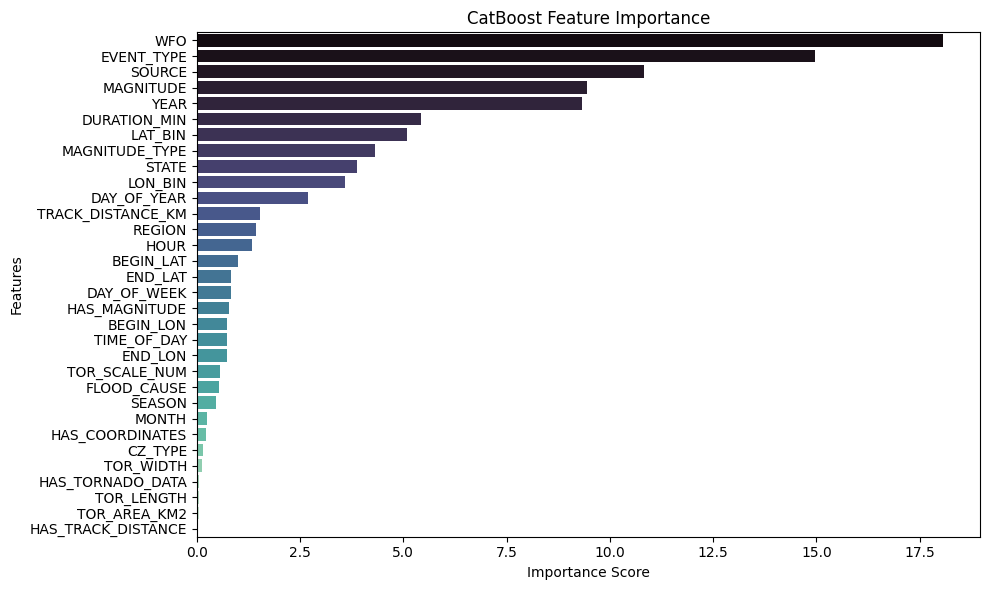

In [10]:
importances = model.get_feature_importance()
feature_names = model.feature_names_

# Pack them into a DataFrame for clean sorting and plotting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Visualize the results
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='mako')
plt.title('CatBoost Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()